In [2]:
# ==============================
# BƯỚC 0: IMPORT + MOUNT DRIVE
# ==============================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

Mounted at /content/drive


In [5]:
# ===============================
# LOAD DỮ LIỆU
# ===============================

digits = np.load(
    "/content/drive/MyDrive/NhanDang/data/digits.npy",
    allow_pickle=True
)

alphas = np.load(
    "/content/drive/MyDrive/NhanDang/data/alphas.npy",
    allow_pickle=True
)

print("Digits shape:", digits.shape)
print("Alphas shape:", alphas.shape)


# ===============================
# TÁCH ẢNH VÀ LABEL TỪ FILE
# ===============================

digit_images = np.array([item[0] for item in digits])
digit_labels = np.array([item[1] for item in digits])

alpha_images = np.array([item[0] for item in alphas])
alpha_labels = np.array([item[1] for item in alphas])

print("Digit images shape:", digit_images.shape)
print("Alpha images shape:", alpha_images.shape)


# ===============================
# GỘP LẠI THÀNH DATASET HOÀN CHỈNH
# ===============================

X = np.concatenate([digit_images, alpha_images], axis=0)
y = np.concatenate([digit_labels, alpha_labels], axis=0)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ===============================
# RESHAPE CHO CNN
# ===============================

X = X.reshape(X.shape[0], 28, 28, 1)

print("Shape sau reshape:", X.shape)


# ===============================
# CHUẨN HÓA
# ===============================

X = X.astype("float32") / 255.0


# ===============================
# ONE HOT ENCODING
# ===============================

from tensorflow.keras.utils import to_categorical

y = to_categorical(y, num_classes=36)

print("Label shape sau one-hot:", y.shape)

Digits shape: (3000, 2)
Alphas shape: (6300, 2)
Digit images shape: (3000, 28, 28, 1)
Alpha images shape: (6300, 28, 28, 1)
X shape: (9300, 28, 28, 1)
y shape: (9300,)
Shape sau reshape: (9300, 28, 28, 1)
Label shape sau one-hot: (9300, 36)


In [6]:
# =================================
# CHIA TRAIN / VALIDATION
# =================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y.argmax(axis=1)
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (7905, 28, 28, 1)
Validation shape: (1395, 28, 28, 1)


In [7]:
# =================================
# BUILD CNN MODEL
# =================================

import tensorflow as tf

model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(36, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 228,388 (892.14 KB)

 Trainable params: 228,388 (892.14 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# =================================
# COMPILE MODEL
# =================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# =================================
# TRAIN MODEL
# =================================

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.1174 - loss: 3.2601 - val_accuracy: 0.8516 - val_loss: 0.7910
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.6900 - loss: 0.9952 - val_accuracy: 0.9584 - val_loss: 0.1980
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8442 - loss: 0.4777 - val_accuracy: 0.9778 - val_loss: 0.0928
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.8918 - loss: 0.3189 - val_accuracy: 0.9849 - val_loss: 0.0579
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9276 - loss: 0.2138 - val_accuracy: 0.9928 - val_loss: 0.0425
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9448 - loss: 0.1699 - val_accuracy: 0.9900 - val_loss: 0.0408
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9551 - loss: 0.1427 - val_accuracy: 0.9914 - val_loss: 0.0265
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9647 - loss: 0.1226 - val_acc

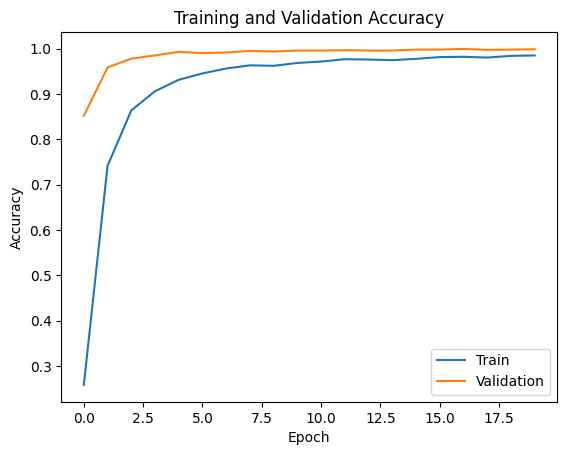

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

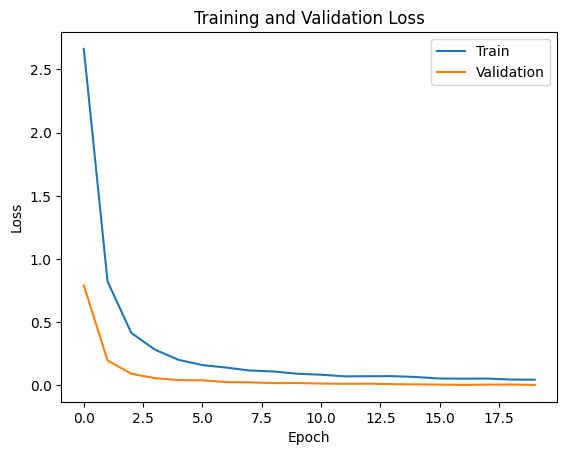

In [11]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [12]:
val_loss, val_accuracy = model.evaluate(X_val, y_val)

print("Validation Accuracy:", val_accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9976 - loss: 0.0054
Validation Accuracy: 0.9985663294792175
